#  العمليات الاساسية على الصور :

 الهدف:

- تعلم ادخال قيم البكسلات
- ادخال قيم خصائص الصور
- وضع مناطق الصورة
- قسم و دمج الصور

تقريباً معظم هذه العمليات تنجز في 
Numpy 
بشكل افضل , من
OpenCV
 ولذلك يجب امتلاك معرفة جيدة بها
 
##  ادخال وتحوير قيم البكسلات:

دعنا نحمل صورة ملونة بالبداية:

In [5]:
import cv2
import numpy as np
img = cv2.imread('apple.png',1)

يمكنك , ادخال قيمة بكسل او عرضها بوساطة احداثيات السطر والعمود ,أما من اجل قيم الصور الملونة , سيتم اعادة , ثلاث قيم للالوان.:

In [6]:
px = img[100,100]
print px

[ 48  93 165]


In [7]:
# accessing only red pixel(bgr)
red = img[100,100,2]
print red

165


 ويمكنك تغيير قيمة البكسلات بنفس الطريقة:

In [8]:
img[100,100] = [255,255,255]
print img[100,100]

[255 255 255]


### ملاحظة:
Numpy
هي مكتبة مؤمثلة لمعالجة المصفوفات بسرعة , لذلك فالدخول لقيم البكسلات كالسابق قد يكون بطيئاً جداً.

### ملاحظة:

الطرق السابقة , تكون بحالة اكثر من عدة بكسلات ,
اما للبكسلات المفردة فيفضل , استخدام التابع
`()array.item`
, ولكنها لا تعطي الا قيمة واحدة , ولذلك يمكن استخدامها ثلاث مرات للصور الملونة
 وهنا طرق افضل للوصول للقيم :


In [9]:
# accessing RED value
img.item(10,10,2)

107

In [10]:
# modifying RED value
img.itemset((10,10,2),100)
img.item(10,10,2)

100

## الدخول لخصائص الصورة
تتضمن خصائص الصورة :عدد القنوات , عدد الاسطر , عدد الاعمدة , عدد البكسلات.
و شكل الصورة يعطى عن طريق

In [11]:
print img.shape

(239, 239, 3)


والعدد الكلي للبكسلات يظهر عبر

In [12]:
print img.size

171363


ونوع بيانات الصورة يعطى ب


In [13]:
print img.dtype

uint8


### ملاحظة:
نوع البيانات هام جداً للصورة لأن عدداً كبيرا من الأخطاء قد يكون عائداً لأمر متعلق به 


## الصورة ROI:

احياناً عليك اللعب مع منطقة محددة من الصور. فمثلاً من اجل اكتشاف العين عليك اولا عليك البحث عن الوجه


ال ROI تكتسب باستخدام ادلة المصفوفة للصورة 
 وهنا سننسخ قسماً من الصورة ونلصقه بمكان آخر.
 

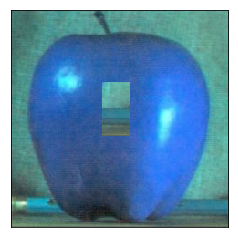

In [16]:
part = img[180:239, 200:230]
img[80:139, 100:130] = part
from matplotlib import pyplot as plt

plt.imshow(img)
plt.xticks([])
plt.yticks([])
plt.show()

### تفريق ودمج قنوات الالوان

المقصود هنا بتفريق الألوان أي فصل الصورة الملونة`rgb` إلى ثلاث صور لكل لون , عبر تابع ما , وكذلك يمكن العكس , أي تجميع ثلاث صور رمادية بنفس القياس لصورة واحدة ملونة
كالتالي:


In [17]:
b,g,r = cv2.split(img)
img = cv2.merge((b,g,r))

In [18]:
# Or
b = img[:,:,0]

افترض انك تريد جعل كل القنوات الحمراء صفرية . يمكنك استخدام الدلائل للمصفوفات وهي اسرع من اضافة مصفوفة صفرية كالسابق , أو من انشاء حلقة 


In [19]:
img[:,:,2] = 0

## تحذير:

`()cv2.split`

هي عملية مكلفة, بدلالة الزمن ,  استخدمها فقط عند الضرورة.
ولذلك بالتالي فاستعمال ادلة المصفوفات افضل كثيراً

## انشاء الحدود للصور:

اذا اردت انشاء حدود للصورة يمكنك استعمال التابع
`()cv2.copyMakeBorder`

ولكن لديه تطبيقات اكثر لعمليات الطي , اضافة الاصفار
:ولهذا التابع المتغيرات التالية

- *صورة يسار*

- *القمة , القاعدة ,اليسار , اليمين:مسافات الحدود*

- *نوع الحدود:وهو متغير يملك القيم التالية*:

    - `cv2.BORDER_CONSTANT`

    - `cv2.BORDER_REFLECT`

    - `cv2.BORDER_REFLECT_101`

    - `cv2.BORDER_REPLICATE`

    - `cv2.BORDER_WRAP`

- *اللون :بحالة النوع الاول للحدود*

للتجريب لكل من الانواع السابقة للحدود نرى الكود التالي:


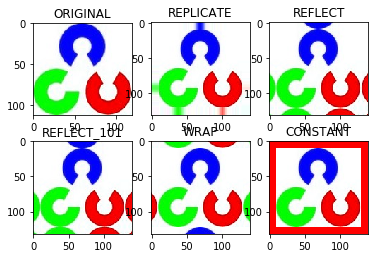

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

BLUE = [255,0,0]

img1 = cv2.imread('..\pic4python\introduction.jpg')

replicate = cv2.copyMakeBorder(img1,10,10,10,10,cv2.BORDER_REPLICATE)
reflect = cv2.copyMakeBorder(img1,10,10,10,10,cv2.BORDER_REFLECT)
reflect101 = cv2.copyMakeBorder(img1,10,10,10,10,cv2.BORDER_REFLECT_101)
wrap = cv2.copyMakeBorder(img1,10,10,10,10,cv2.BORDER_WRAP)
constant= cv2.copyMakeBorder(img1,10,10,10,10,cv2.BORDER_CONSTANT,value=BLUE)

plt.subplot(231),plt.imshow(img1,'gray'),plt.title('ORIGINAL')
plt.subplot(232),plt.imshow(replicate,'gray'),plt.title('REPLICATE')
plt.subplot(233),plt.imshow(reflect,'gray'),plt.title('REFLECT')
plt.subplot(234),plt.imshow(reflect101,'gray'),plt.title('REFLECT_101')
plt.subplot(235),plt.imshow(wrap,'gray'),plt.title('WRAP')
plt.subplot(236),plt.imshow(constant,'gray'),plt.title('CONSTANT')

plt.show()

## العمليات الجبرية على الصور:

الهدف:

تعلم التوابع التالية: 

`cv2.add` , `cv2.addWeighted`

### جمع الصور:

يمكنك جمع صورتين من خلال تابع
`()cv2.add`
او ببساطة من خلال جمع المصفوفات , لكن كل من المصفوفتين يجب ان تملك نفس النوع والأبعاد , او يمكن للصورة الثانية ان تكون قيمة صحيحة.

### ملاحظة
هناك فرق بين عمليات جمع عددية بوساطة
numpy
 وعمليات الجمع بوساطة opencv
فالاولى هي عملية طرحية , اما الثانية فهي جمع مشبع
:والتالي كمثال


In [2]:
x = np.uint8([250])
y = np.uint8([10])

In [3]:
print cv2.add(x,y) # 250+10 = 260 => 255

[[255]]


In [4]:
print x+y  # 250+10 = 260 % 256 = 4

[4]


وستكون تلك النتائج واضحة بحالة جمع صورتين , ولما كانت نتائج 
opencv
افضل , فيجب دائماً استخدامها.


## Image Blending دمج الصورة

هنا ايضاً جمع للصور ولكن كل منها له وزن مختلف, بحيث تعطي انطباع الدمج الشاف

$$ g(x) = (1- \alpha) f_0(x) + \alpha f_1(x) $$

وبتبديل القيمة للمتغير الفا من 0 ل 1 ,يمكن انتاج تحويل رائع للصور من واحدة لاخرى
وهنا اخذت صورتين لدمجهم معاً , اول صورة تعطى الوزن :0.7 والثانية الوزن 0.3 عبر التابع
`cv2.addWeighted`
الذي يطبق المعادلة السابقة
كما التالي:


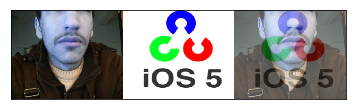

In [6]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

img1 = cv2.imread('..\pic4python\Me.jpg',1)
img2 = cv2.imread('..\pic4python\opencv_ios.png',1)

# 600X600 sound cool
# img2 = cv2.resize(img2,(img1.shape[1],img1.shape[0]))
img2 = cv2.resize(img2,(750,600))
img1 = cv2.resize(img1,(750,600))

dst = cv2.addWeighted(img1,0.7,img2,0.3,0)

# cv2.namedWindow('dst',cv2.WINDOW_NORMAL)
res = np.hstack([img1,img2,dst])

plt.imshow(res)
plt.xticks([])
plt.yticks([])
plt.show()

## العمليات على مستوى البت:

وهذا بتضمن عمليات:

`AND,OR,XOR,NOT`.

 وهذه ستكون بفائدة عظمى عند الاشتقاق من اي جزء من الصورة 
لتحديد الاجزاء غير المستطيلة من الصورة ,يسمى هذا **بالتقنيع ** , وفيما يلي مثال على تغيير جزء محدد من الصورة.

-  فيما يلي سنضع شعار مكتبة OpenCV في زاوية صورة أخرى

-  وذلك لا يتم بالجمع , لان اللون سيتغير ولا بالدمج لان اللون سيصبح شفافاً , ولن ينفع بالاسناد لان الشكل ليس مستطيلاً لذلك نقوم به كالتالي


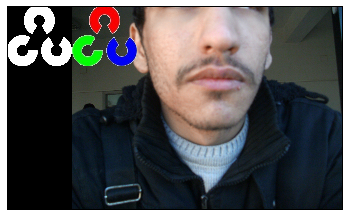

In [46]:
# -*- coding: utf-8 -*-
"""
Created on Thu Nov 19 11:49:35 2015

@author: External
"""

import cv2
import numpy as np
from matplotlib import pyplot as plt

img = cv2.imread('C:\Users\External\Documents\myPythonFiles\pic4python\Me.jpg',1)

# invert color to show with mayplotlib
b,g,r = cv2.split(img)
img = cv2.merge((r,g,b))
# grayscale logo
logo = cv2.imread('C:\Users\External\Documents\myPythonFiles\pic4python\introduction.jpg',1)

# invert color to show with mayplotlib
b,g,r = cv2.split(logo)
logo = cv2.merge((r,g,b))

imgsize = img.shape
originalsize = logo.shape
nhight = imgsize[0]*0.30
nwidth = int((nhight/originalsize[0])*originalsize[1])
nhight = int(nhight)
logo = cv2.resize(logo,(nwidth,nhight))

# take the roi of the image
roi = img[0:nhight,0:nwidth]

# Create mask and inverse mask
logo2gray = cv2.cvtColor(logo,cv2.COLOR_BGR2GRAY)
ret,mask_inv = cv2.threshold(logo2gray,225,255,cv2.THRESH_BINARY)
mask = cv2.bitwise_not(mask_inv)

#Now Black out the area of logo.
img1_bg = cv2.bitwise_and(roi,roi,mask=mask_inv)

# Take only region of logo from logo image
img2_fg = cv2.bitwise_and(logo,logo,mask = mask)

#put logo in the roi
dst = cv2.add(img1_bg,img2_fg)
img[0:nhight,0:nwidth] = dst

bar = np.zeros([imgsize[0]-nhight,nwidth],np.uint8)
explin = np.vstack((mask,bar))
explin = cv2.merge((explin,explin,explin))
res = np.hstack((explin,img))

# show result:
plt.imshow(res)
plt.xticks([])
plt.yticks([])
plt.show()

النتائج اعلاه . تظهر بها , القناع الذي تم انشاؤه. الصورة اليمنى تظهر النتيجة النهائية ,
ويمكنك لفهم اكثر , اظهار كل الصور التي تم اشتقاقها اعلاه

## تمرين: 

انشئ عرض شرائح اعلاه للصور بمجلد مع انتقال طفيف بين الصور , بالستخدام التابع 
`cv2.addWeighted` .
